# Basline classifier using 1D CNN for time series data

In [2]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scripts.load import make_loader, ACTIVITY_NAMES, make_confusion
from scripts.train_cls import train_baseline
from src.models import BaselineCNN

In [2]:
PROCESSED_DIR = PROJECT_ROOT / 'dataset' / 'processed'
MODEL_DIR = PROJECT_ROOT / "models"
data = np.load(PROCESSED_DIR / 'splits.npz')

X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']
y_train = data['y_train']
y_val   = data['y_val']
y_test  = data['y_test']

print('Train:', X_train.shape, 'labels:', y_train.shape)
print('Val  :', X_val.shape)
print('Test :', X_test.shape)

Train: (14525, 6, 300) labels: (14525,)
Val  : (2075, 6, 300)
Test : (4150, 6, 300)


In [3]:
train_loader = make_loader(X_train, y_train, batch_size=128, shuffle=True)
val_loader   = make_loader(X_val, y_val, batch_size=128)
test_loader  = make_loader(X_test, y_test, batch_size=128)

In [4]:
device="cpu"
model = BaselineCNN()
model, train_losses, val_losses, val_accs = train_baseline(
    model,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3,
    device=device
)
torch.save(model.state_dict(), MODEL_DIR / 'baseline_classifier.pth')

Baseline Epoch 1 | Train Loss: 1.6241 | Val Loss: 1.2550 | Val Acc: 0.5248
Baseline Epoch 2 | Train Loss: 0.9603 | Val Loss: 0.7614 | Val Acc: 0.6988
Baseline Epoch 3 | Train Loss: 0.7656 | Val Loss: 0.6069 | Val Acc: 0.7653
Baseline Epoch 4 | Train Loss: 0.6576 | Val Loss: 0.6040 | Val Acc: 0.7542
Baseline Epoch 5 | Train Loss: 0.5882 | Val Loss: 0.5363 | Val Acc: 0.7928
Baseline Epoch 6 | Train Loss: 0.5355 | Val Loss: 0.5531 | Val Acc: 0.7590
Baseline Epoch 7 | Train Loss: 0.4862 | Val Loss: 0.4699 | Val Acc: 0.8106
Baseline Epoch 8 | Train Loss: 0.4427 | Val Loss: 0.4068 | Val Acc: 0.8424
Baseline Epoch 9 | Train Loss: 0.4220 | Val Loss: 0.4838 | Val Acc: 0.7923
Baseline Epoch 10 | Train Loss: 0.3877 | Val Loss: 0.4095 | Val Acc: 0.8641
Baseline Epoch 11 | Train Loss: 0.3585 | Val Loss: 0.3375 | Val Acc: 0.8545
Baseline Epoch 12 | Train Loss: 0.3594 | Val Loss: 0.3212 | Val Acc: 0.8848
Baseline Epoch 13 | Train Loss: 0.3210 | Val Loss: 0.3717 | Val Acc: 0.8400
Baseline Epoch 14 | T

## Evaluation

In [5]:
def train_val_curves(train_losses, val_losses, val_accs):
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, train_losses, 'b-', label='Train Loss')
    ax1.plot(epochs, val_losses, 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, val_accs, 'g-', label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

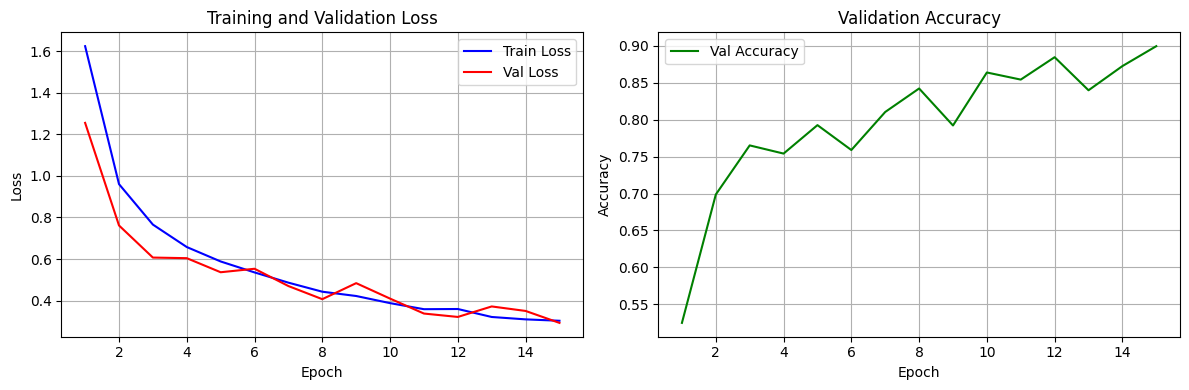

In [6]:
train_val_curves(train_losses, val_losses, val_accs)

In [7]:
def evaluate(model, loader, device="cpu"):
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X)
            preds = out.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')

    return acc, f1

In [8]:
model = BaselineCNN().to(device="cpu")
model.load_state_dict(torch.load(MODEL_DIR / "baseline_classifier.pth"))
model.eval()

test_acc, test_f1 = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)
print("Test Macro F1:", test_f1)

Test Accuracy: 0.903855421686747
Test Macro F1: 0.9079624732022027


In [9]:
def full_report(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X)
            preds = out.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    print(classification_report(all_labels, all_preds))

full_report(model, test_loader)

              precision    recall  f1-score   support

           0       0.69      0.94      0.80       377
           1       0.84      0.65      0.73       375
           2       0.93      0.95      0.94       359
           3       0.92      0.97      0.94       373
           4       0.98      0.99      0.99       436
           5       0.96      0.81      0.88       363
           6       0.91      0.95      0.93       352
           7       0.99      0.88      0.93       267
           8       0.97      0.95      0.96       133
           9       0.98      0.96      0.97        96
          10       0.90      0.98      0.94       201
          11       0.96      0.93      0.94       176
          12       1.00      0.95      0.98        63
          13       0.71      0.79      0.75        52
          14       1.00      0.82      0.90       119
          15       0.94      0.96      0.95       160
          16       0.89      0.92      0.91       156
          17       0.99    

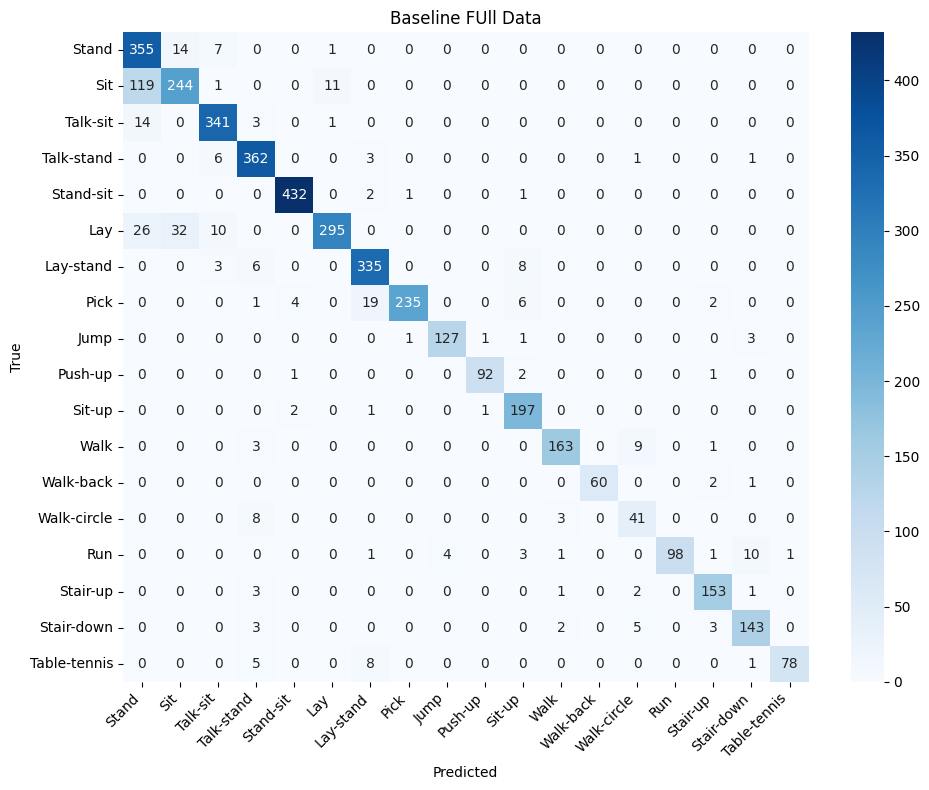

In [10]:
make_confusion(model, test_loader, title="Baseline FUll Data")

## 20% labeled data

In [11]:
def sample_labels(X, y, fraction, random_state=42):
    if fraction >= 1.0:
        return X, y
    _, X_f, _, y_f = train_test_split(X, y, test_size=fraction, stratify=y, random_state=random_state)
    return X_f, y_f

In [12]:
X_small, y_small = sample_labels(X_train, y_train, fraction=0.2)
train_loader_small = make_loader(X_small, y_small, batch_size=128, shuffle=True)

classifier_small = BaselineCNN()
model_small, train_losses_small, val_losses_small, accs_small = train_baseline(
    classifier_small,
    train_loader_small,
    val_loader,
    epochs=15,
    lr=1e-3,
    device=device
)

torch.save(model_small.state_dict(), MODEL_DIR / 'baseline_20.pth')

Baseline Epoch 1 | Train Loss: 2.2868 | Val Loss: 2.0155 | Val Acc: 0.3060
Baseline Epoch 2 | Train Loss: 1.7935 | Val Loss: 1.6547 | Val Acc: 0.4145
Baseline Epoch 3 | Train Loss: 1.5107 | Val Loss: 1.4520 | Val Acc: 0.4463
Baseline Epoch 4 | Train Loss: 1.2613 | Val Loss: 1.2930 | Val Acc: 0.5128
Baseline Epoch 5 | Train Loss: 1.0893 | Val Loss: 1.1169 | Val Acc: 0.5639
Baseline Epoch 6 | Train Loss: 0.9818 | Val Loss: 1.1622 | Val Acc: 0.5388
Baseline Epoch 7 | Train Loss: 0.8769 | Val Loss: 1.0884 | Val Acc: 0.5663
Baseline Epoch 8 | Train Loss: 0.8062 | Val Loss: 1.0046 | Val Acc: 0.6202
Baseline Epoch 9 | Train Loss: 0.7277 | Val Loss: 1.1132 | Val Acc: 0.5961
Baseline Epoch 10 | Train Loss: 0.6984 | Val Loss: 0.9762 | Val Acc: 0.6347
Baseline Epoch 11 | Train Loss: 0.6631 | Val Loss: 0.8511 | Val Acc: 0.6814
Baseline Epoch 12 | Train Loss: 0.6200 | Val Loss: 0.7801 | Val Acc: 0.7070
Baseline Epoch 13 | Train Loss: 0.5965 | Val Loss: 0.9482 | Val Acc: 0.6670
Baseline Epoch 14 | T

In [13]:
model_small = BaselineCNN().to(device="cpu")
model_small.load_state_dict(torch.load(MODEL_DIR / "baseline_20.pth"))

test_acc, test_f1 = evaluate(model_small, test_loader)

print("Baseline 20% -> Test Acc:", test_acc)
print("Baseline 20% -> Test F1 :", test_f1)

Baseline 20% -> Test Acc: 0.7060240963855422
Baseline 20% -> Test F1 : 0.6574164661141603


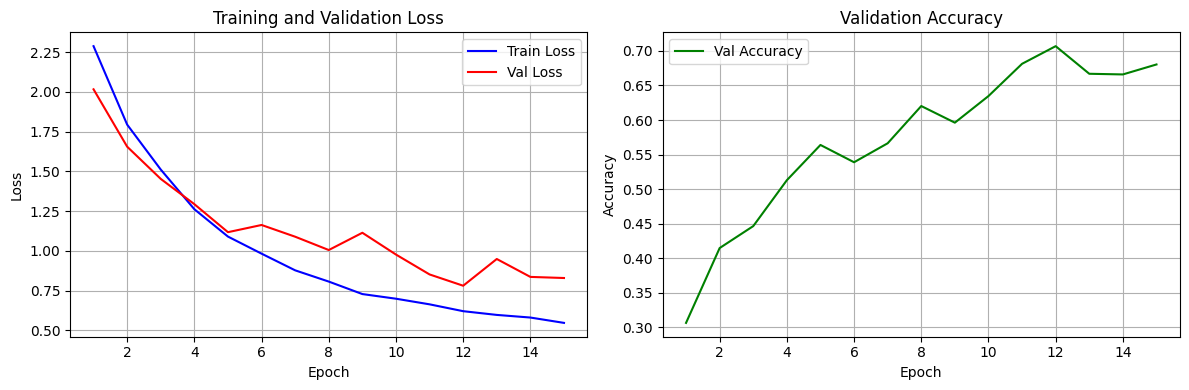

In [16]:
train_val_curves(train_losses_small, val_losses_small, accs_small)

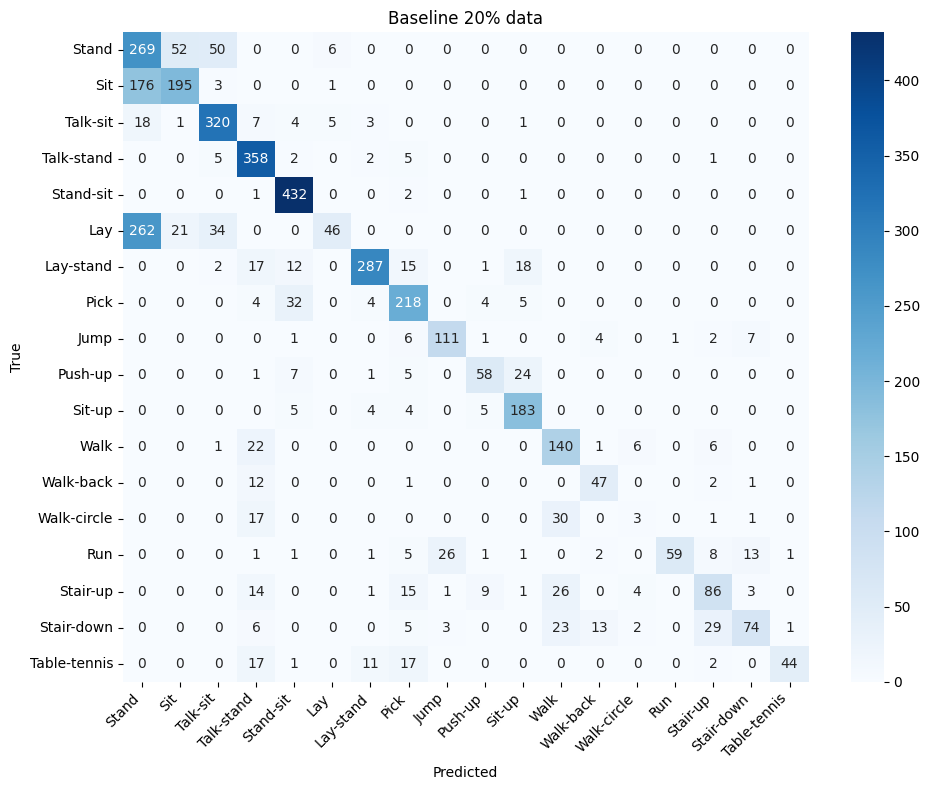

In [15]:
make_confusion(model_small, test_loader, title="Baseline 20% data")